# 3.4 Inverse

Layouts may be injective, surjective, or bijective and admit right-, left-, full-, and quasi-inverses. When layouts are interpreted as functions from coordinates to offsets, inverse layouts may be interpreted as functions from offsets to coordinates. Layout inverses are very useful in determining where within a layout certain offsets exist, extracting groups of specific offsets, or determining the common sublayout of two individual layouts.

In this section, we define the generalized left- and right-inverses of a layout and provide application examples for their use.

In [1]:
from tensor_layouts import Layout, size, cosize, rank, depth, mode, flatten, coalesce
from tensor_layouts import compose, right_inverse, left_inverse, max_common_layout
from tensor_layouts.viz import draw_layout, show_layout

## 3.4.1 Right-Inverse

A right-(pseudo)inverse of a layout $L : \mathbb{Z}_{|L|} \to D$ is an injective layout $L^\ddagger : D_{L^\ddagger} \to \mathbb{Z}_{|L|}$ that satisfies

$$\forall k \in D_{L^\ddagger},\; L^\ddagger(L(L^\ddagger(k))) = L^\ddagger(k) \qquad (24)$$

In the common case $D = \mathbb{Z}$, the canonical right-inverse definition is recovered,

$$\forall k \in \mathbb{Z}_{|L^\ddagger|},\; L(L^\ddagger(k)) = k$$

If a layout $L$ has a right-inverse layout $L^\ddagger$, then $|L^\ddagger| \le |L|$. In practice, when referencing the right-inverse of a layout, we typically mean the right-inverse with the maximum size.

In [2]:
# Table 5: Examples of layout right-inverses
examples = [
    (Layout((4, 8), (1, 4)),                          "(4,8):(1,4)"),
    (Layout((4, 8), (8, 1)),                          "(4,8):(8,1)"),
    (Layout((3, 7, 5), (5, 15, 1)),                   "(3,7,5):(5,15,1)"),
    (Layout((4, 8), (1, 5)),                          "(4,8):(1,5)  — non-contiguous"),
    (Layout((4, (4, 2)), (4, (1, 16))),               "(4,(4,2)):(4,(1,16))"),
    (Layout(((2, 2), (4, 2)), ((1, 8), (2, 16))),    "((2,2),(4,2)):((1,8),(2,16))"),
    (Layout(((2, 2), (2, 4)), ((0, 1), (0, 2))),     "((2,2),(2,4)):((0,1),(0,2))  — stride-0"),
]

for L, desc in examples:
    R = right_inverse(L)
    print(f"L = {desc}")
    print(f"  L‡ = {R}  (size {size(R)})")
    print()

L = (4,8):(1,4)
  L‡ = 32 : 1  (size 32)

L = (4,8):(8,1)
  L‡ = (8, 4) : (4, 1)  (size 32)

L = (3,7,5):(5,15,1)
  L‡ = (5, 21) : (21, 1)  (size 105)

L = (4,8):(1,5)  — non-contiguous
  L‡ = 4 : 1  (size 4)

L = (4,(4,2)):(4,(1,16))
  L‡ = (4, 4, 2) : (4, 1, 16)  (size 32)

L = ((2,2),(4,2)):((1,8),(2,16))
  L‡ = (2, 4, 2, 2) : (1, 4, 2, 16)  (size 32)

L = ((2,2),(2,4)):((0,1),(0,2))  — stride-0
  L‡ = 1 : 0  (size 1)



In [3]:
# Verify the right-inverse property: L(L‡(k)) = k for all k in the domain of L‡
L = Layout((4, 8), (1, 4))
R = right_inverse(L)
print(f"L = {L}")
print(f"L‡ = {R}")
print()

# Check: L(L‡(k)) = k
print("Verifying L(L‡(k)) = k:")
for k in range(min(size(R), 8)):
    r_k = R(k)
    l_r_k = L(r_k)
    print(f"  k={k}: L‡(k)={r_k}, L(L‡(k))={l_r_k}")

assert all(L(R(k)) == k for k in range(size(R)))
print(f"\nRight-inverse property holds for all {size(R)} elements.")

L = (4, 8) : (1, 4)
L‡ = 32 : 1

Verifying L(L‡(k)) = k:
  k=0: L‡(k)=0, L(L‡(k))=0
  k=1: L‡(k)=1, L(L‡(k))=1
  k=2: L‡(k)=2, L(L‡(k))=2
  k=3: L‡(k)=3, L(L‡(k))=3
  k=4: L‡(k)=4, L(L‡(k))=4
  k=5: L‡(k)=5, L(L‡(k))=5
  k=6: L‡(k)=6, L(L‡(k))=6
  k=7: L‡(k)=7, L(L‡(k))=7

Right-inverse property holds for all 32 elements.


In [4]:
# For non-contiguous layouts, the right-inverse is smaller
L_nc = Layout((4, 8), (1, 5))
R_nc = right_inverse(L_nc)
print(f"L = {L_nc}  (size {size(L_nc)}, cosize {cosize(L_nc)})")
print(f"L‡ = {R_nc}  (size {size(R_nc)})")
print()
print(f"Only {size(R_nc)} of {size(L_nc)} elements can be recovered — the contiguous prefix.")
print(f"Offsets in image: {sorted(set(L_nc(k) for k in range(size(L_nc))))}")
print()

# Verify right-inverse still holds on its domain
assert all(L_nc(R_nc(k)) == k for k in range(size(R_nc)))
print(f"Right-inverse property holds for all {size(R_nc)} elements in domain.")

L = (4, 8) : (1, 5)  (size 32, cosize 39)
L‡ = 4 : 1  (size 4)

Only 4 of 32 elements can be recovered — the contiguous prefix.
Offsets in image: [0, 1, 2, 3, 5, 6, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18, 20, 21, 22, 23, 25, 26, 27, 28, 30, 31, 32, 33, 35, 36, 37, 38]

Right-inverse property holds for all 4 elements in domain.


When the layout $L$ is a bijection on $\mathbb{Z}_{|L|}$, then the right-inverse is also the inverse, $L^{-1}$, of the layout $L$ and satisfies

$$\forall k \in \mathbb{Z}_{|L|},\; L(L^{-1}(k)) = k = L^{-1}(L(k))$$

If a layout $L$ has a full-inverse $L^{-1}$ we call that layout *compact*.

In [5]:
# A compact (bijective) layout: the right-inverse is a true inverse
L = Layout((4, 8), (8, 1))
R = right_inverse(L)
print(f"L  = {L}  (row-major 4x8)")
print(f"L‡ = {R}  (its inverse)")
print()

# Verify BOTH directions: L(L‡(k)) = k AND L‡(L(k)) = k
assert all(L(R(k)) == k for k in range(size(R)))
assert all(R(L(k)) == k for k in range(size(L)))
print(f"Full inverse: L(L⁻¹(k))=k and L⁻¹(L(k))=k for all k in Z_{size(L)}.")
print(f"This layout is compact (bijective on Z_{size(L)}).")

L  = (4, 8) : (8, 1)  (row-major 4x8)
L‡ = (8, 4) : (4, 1)  (its inverse)

Full inverse: L(L⁻¹(k))=k and L⁻¹(L(k))=k for all k in Z_32.
This layout is compact (bijective on Z_32).


## 3.4.2 Application: Vectorization Example

Right inverses are extremely useful in inspecting data layouts and determining if and where contiguous elements exist. As an immediate example, the right-inverse of the layouts $(4,8):(1,4)$ and $(4,8):(8,1)$ are $32:1$ and $(8,4):(4,1)$ respectively. This means that both layouts, because their right-inverses have size-32, index into 32 contiguous physical elements.

As a more involved example, a common pattern for copy, called a vectorizing-copy in CuTe, attempts to find the maximum number of elements that can be copied at once between two tensors. The right-inverse allows CuTe to determine the maximum common sublayout between two layouts and, with additional information regarding hardware capabilities and physical alignment of pointers and strides, can algebraically determine the number and location of elements that can be safely vectorized to perform the copy.

Source: (4, 4) : (1, 4)


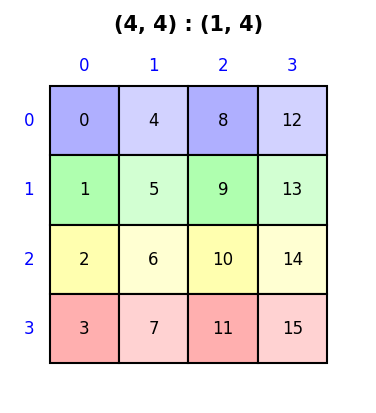

Destination: ((2, 2), 4) : ((1, 8), 2)


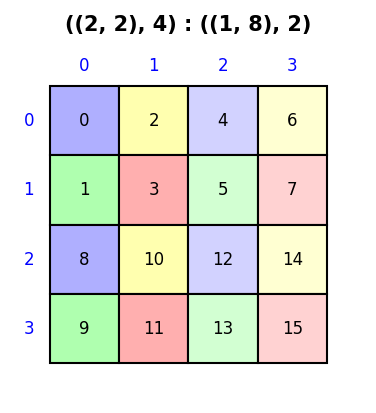

In [6]:
# Figure 8a: A 2-element common subvector
source_a = Layout((4, 4), (1, 4))
dest_a   = Layout(((2, 2), 4), ((1, 8), 2))

print("Source:", source_a)
draw_layout(source_a, colorize=True)
print("Destination:", dest_a)
draw_layout(dest_a, colorize=True)

In general, for layout $A : \mathbb{Z}_{(A)} \to \mathbb{Z}_\alpha$ and $B : \mathbb{Z}_{(B)} \to \mathbb{Z}_\beta$ with $|A| = |B|$, we wish to find the largest integer $K$ such that the coordinates match

$$\forall k \in \mathbb{Z}_K,\; A^\ddagger(k) = B^\ddagger(k)$$

and this can be computed efficiently via finding $K$ such that

$$\forall k \in \mathbb{Z}_K,\; k = A(B^\ddagger(k)) = (A \circ B^\ddagger)(k)$$

or

$$\forall k \in \mathbb{Z}_K,\; k = B(A^\ddagger(k)) = (B \circ A^\ddagger)(k)$$

which is simply the size of the identity portion (the stride-1 mode) of $A \circ B^\ddagger = (I_K, X)$ or $B \circ A^\ddagger = (I_K, Y)$.

In [7]:
# Compute the common subvector for Figure 8a
A, B = source_a, dest_a

B_ri = right_inverse(B)
comp = compose(A, B_ri)
print(f"A = {A}")
print(f"B = {B}")
print(f"B‡ = {B_ri}")
print(f"A ∘ B‡ = {comp}")
print()

# The identity prefix is the stride-1 mode at the front
print("Values of (A ∘ B‡)(k):")
for k in range(size(comp)):
    v = comp(k)
    marker = "  <-- identity" if v == k else ""
    print(f"  k={k}: (A ∘ B‡)({k}) = {v}{marker}")

# Use max_common_layout for the direct answer
mcl = max_common_layout(A, B)
print(f"\nmax_common_layout(A, B) = {mcl}  (size {size(mcl)})")
print(f"=> {size(mcl)} elements can be copied at once per vectorized instruction.")

A = (4, 4) : (1, 4)
B = ((2, 2), 4) : ((1, 8), 2)
B‡ = (2, 4, 2) : (1, 4, 2)
A ∘ B‡ = (2, 4, 2) : (1, 4, 2)

Values of (A ∘ B‡)(k):
  k=0: (A ∘ B‡)(0) = 0  <-- identity
  k=1: (A ∘ B‡)(1) = 1  <-- identity
  k=2: (A ∘ B‡)(2) = 4
  k=3: (A ∘ B‡)(3) = 5
  k=4: (A ∘ B‡)(4) = 8
  k=5: (A ∘ B‡)(5) = 9
  k=6: (A ∘ B‡)(6) = 12
  k=7: (A ∘ B‡)(7) = 13
  k=8: (A ∘ B‡)(8) = 2
  k=9: (A ∘ B‡)(9) = 3
  k=10: (A ∘ B‡)(10) = 6
  k=11: (A ∘ B‡)(11) = 7
  k=12: (A ∘ B‡)(12) = 10
  k=13: (A ∘ B‡)(13) = 11
  k=14: (A ∘ B‡)(14) = 14  <-- identity
  k=15: (A ∘ B‡)(15) = 15  <-- identity

max_common_layout(A, B) = 2 : 1  (size 2)
=> 2 elements can be copied at once per vectorized instruction.


Source: ((2, 2), (2, 2)) : ((8, 2), (4, 1))


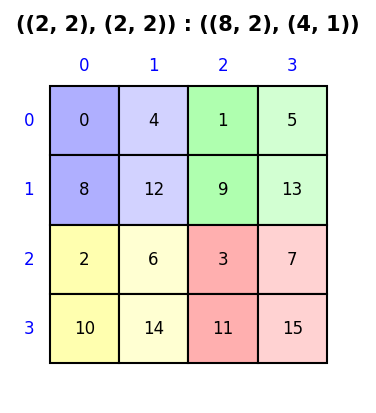

Destination: ((2, 2), (2, 2)) : ((4, 2), (8, 1))


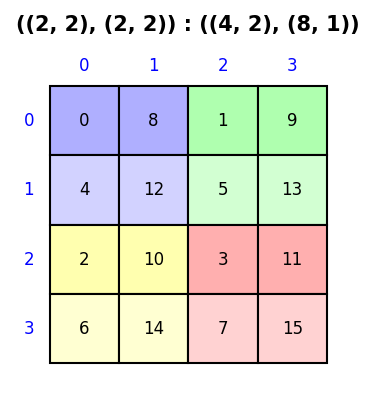

In [8]:
# Figure 8b: A 4-element common subvector
source_b = Layout(((2, 2), (2, 2)), ((8, 2), (4, 1)))
dest_b   = Layout(((2, 2), (2, 2)), ((4, 2), (8, 1)))

print("Source:", source_b)
draw_layout(source_b, colorize=True)
print("Destination:", dest_b)
draw_layout(dest_b, colorize=True)

In [9]:
A2, B2 = source_b, dest_b

B2_ri = right_inverse(B2)
comp2 = compose(A2, B2_ri)
print(f"A = {A2}")
print(f"B = {B2}")
print(f"B‡ = {B2_ri}")
print(f"A ∘ B‡ = {comp2}")
print()

print("Values of (A ∘ B‡)(k):")
for k in range(size(comp2)):
    v = comp2(k)
    marker = "  <-- identity" if v == k else ""
    print(f"  k={k}: (A ∘ B‡)({k}) = {v}{marker}")

mcl2 = max_common_layout(A2, B2)
print(f"\nmax_common_layout(A, B) = {mcl2}  (size {size(mcl2)})")
print(f"=> {size(mcl2)} elements can be copied at once per vectorized instruction.")

A = ((2, 2), (2, 2)) : ((8, 2), (4, 1))
B = ((2, 2), (2, 2)) : ((4, 2), (8, 1))
B‡ = (2, 2, 2, 2) : (8, 2, 1, 4)
A ∘ B‡ = (2, 2, 2, 2) : (1, 2, 8, 4)

Values of (A ∘ B‡)(k):
  k=0: (A ∘ B‡)(0) = 0  <-- identity
  k=1: (A ∘ B‡)(1) = 1  <-- identity
  k=2: (A ∘ B‡)(2) = 2  <-- identity
  k=3: (A ∘ B‡)(3) = 3  <-- identity
  k=4: (A ∘ B‡)(4) = 8
  k=5: (A ∘ B‡)(5) = 9
  k=6: (A ∘ B‡)(6) = 10
  k=7: (A ∘ B‡)(7) = 11
  k=8: (A ∘ B‡)(8) = 4
  k=9: (A ∘ B‡)(9) = 5
  k=10: (A ∘ B‡)(10) = 6
  k=11: (A ∘ B‡)(11) = 7
  k=12: (A ∘ B‡)(12) = 12  <-- identity
  k=13: (A ∘ B‡)(13) = 13  <-- identity
  k=14: (A ∘ B‡)(14) = 14  <-- identity
  k=15: (A ∘ B‡)(15) = 15  <-- identity

max_common_layout(A, B) = (2, 2) : (8, 2)  (size 4)
=> 4 elements can be copied at once per vectorized instruction.


Moreover, the integral coordinates of these mutually contiguous elements is given by

$$A^\ddagger \circ \lfloor B \circ A^\ddagger \rfloor_K = A^\ddagger \circ I_K = \lfloor A^\ddagger \rfloor_K : \mathbb{Z}_K \to \mathbb{Z}_{|A|}$$
$$B^\ddagger \circ \lfloor A \circ B^\ddagger \rfloor_K = B^\ddagger \circ I_K = \lfloor B^\ddagger \rfloor_K : \mathbb{Z}_K \to \mathbb{Z}_{|B|}$$

where $\lfloor \cdot \rfloor_K$ is a truncated-at-size-$K$ operation. This layout yields the logical coordinates of the first $K$ physical elements in the data and could be used to extract out the common subvectors from each via logical divide or zipped divide.

In [10]:
# Show which logical coordinates correspond to the common subvector
# For Figure 8a: K=2, the first 2 physical offsets (0,1) are common
A, B = source_a, dest_a
mcl = max_common_layout(A, B)
K = size(mcl)

A_ri = right_inverse(A)
B_ri = right_inverse(B)

print(f"Figure 8a: K={K} common elements")
print(f"  In source coords: {[A_ri(k) for k in range(K)]}")
print(f"  In dest coords:   {[B_ri(k) for k in range(K)]}")
print(f"  Both map to physical offsets: {[A(A_ri(k)) for k in range(K)]}")
print()

# For Figure 8b: K=4
A2, B2 = source_b, dest_b
mcl2 = max_common_layout(A2, B2)
K2 = size(mcl2)

A2_ri = right_inverse(A2)
B2_ri = right_inverse(B2)

print(f"Figure 8b: K={K2} common elements")
print(f"  In source coords: {[A2_ri(k) for k in range(K2)]}")
print(f"  In dest coords:   {[B2_ri(k) for k in range(K2)]}")
print(f"  Both map to physical offsets: {[A2(A2_ri(k)) for k in range(K2)]}")

Figure 8a: K=2 common elements
  In source coords: [0, 1]
  In dest coords:   [0, 1]
  Both map to physical offsets: [0, 1]

Figure 8b: K=4 common elements
  In source coords: [0, 8, 2, 10]
  In dest coords:   [0, 8, 2, 10]
  Both map to physical offsets: [0, 1, 2, 3]


## 3.4.3 Left-Inverse

A left-(pseudo)inverse of a layout $L : \mathbb{Z}_{|L|} \to D$ is a layout $L^\dagger : D_{L^\dagger} \to \mathbb{Z}_{|L|}$ that satisfies

$$\forall k \in \mathbb{Z}_{|L|},\; L(L^\dagger(L(k))) = L(k) \qquad (26)$$

The left inverse may not be unique and may take any values for inputs that are not in the image of $L$. In the common case where $L$ is injective, the canonical left-inverse definition is recovered,

$$\forall k \in \mathbb{Z}_{|L|},\; L^\dagger(L(k)) = k.$$

In [11]:
# Table 6: Examples of layout left-inverses
examples = [
    (Layout((4, 8), (1, 4)),                          "(4,8):(1,4)"),
    (Layout((4, 8), (8, 1)),                          "(4,8):(8,1)"),
    (Layout((3, 7, 5), (5, 15, 1)),                   "(3,7,5):(5,15,1)"),
    (Layout((4, (4, 2)), (4, (1, 16))),               "(4,(4,2)):(4,(1,16))"),
    (Layout(((2, 2), (4, 2)), ((1, 8), (2, 16))),    "((2,2),(4,2)):((1,8),(2,16))"),
]

for L, desc in examples:
    Li = left_inverse(L)
    print(f"L = {desc}")
    print(f"  L† = {Li}  (size {size(Li)})")
    print()

L = (4,8):(1,4)
  L† = 32 : 1  (size 32)

L = (4,8):(8,1)
  L† = (8, 4) : (4, 1)  (size 32)

L = (3,7,5):(5,15,1)
  L† = (5, 21) : (21, 1)  (size 105)

L = (4,(4,2)):(4,(1,16))
  L† = (4, 4, 2) : (4, 1, 16)  (size 32)

L = ((2,2),(4,2)):((1,8),(2,16))
  L† = (2, 4, 2, 2) : (1, 4, 2, 16)  (size 32)



In [12]:
# Verify the left-inverse property for injective layouts: L†(L(k)) = k
L = Layout((4, 8), (8, 1))
Li = left_inverse(L)
print(f"L  = {L}  (row-major 4x8)")
print(f"L† = {Li}")
print()

print("Verifying L†(L(k)) = k:")
for k in range(min(size(L), 8)):
    lk = L(k)
    li_lk = Li(lk)
    print(f"  k={k}: L(k)={lk}, L†(L(k))={li_lk}")

assert all(Li(L(k)) == k for k in range(size(L)))
print(f"\nLeft-inverse property L†(L(k))=k holds for all {size(L)} elements.")

L  = (4, 8) : (8, 1)  (row-major 4x8)
L† = (8, 4) : (4, 1)

Verifying L†(L(k)) = k:
  k=0: L(k)=0, L†(L(k))=0
  k=1: L(k)=8, L†(L(k))=1
  k=2: L(k)=16, L†(L(k))=2
  k=3: L(k)=24, L†(L(k))=3
  k=4: L(k)=1, L†(L(k))=4
  k=5: L(k)=9, L†(L(k))=5
  k=6: L(k)=17, L†(L(k))=6
  k=7: L(k)=25, L†(L(k))=7

Left-inverse property L†(L(k))=k holds for all 32 elements.


For contiguous (compact/bijective) layouts, the left- and right-inverses coincide. For non-contiguous layouts, they may differ: the right-inverse has size equal to the number of contiguous offsets from 0, while the left-inverse covers enough of the codomain to invert all values in the image.

In [13]:
# Compare left- and right-inverses
layouts = [
    (Layout((4, 8), (1, 4)),       "bijective (col-major)"),
    (Layout((4, 8), (8, 1)),       "bijective (row-major)"),
    (Layout((3, 7, 5), (5, 15, 1)), "bijective (3D)"),
]

for L, desc in layouts:
    ri = right_inverse(L)
    li = left_inverse(L)
    print(f"L = {L}  ({desc})")
    print(f"  Right-inverse: {ri}  (size {size(ri)})")
    print(f"  Left-inverse:  {li}  (size {size(li)})")
    print()

L = (4, 8) : (1, 4)  (bijective (col-major))
  Right-inverse: 32 : 1  (size 32)
  Left-inverse:  32 : 1  (size 32)

L = (4, 8) : (8, 1)  (bijective (row-major))
  Right-inverse: (8, 4) : (4, 1)  (size 32)
  Left-inverse:  (8, 4) : (4, 1)  (size 32)

L = (3, 7, 5) : (5, 15, 1)  (bijective (3D))
  Right-inverse: (5, 21) : (21, 1)  (size 105)
  Left-inverse:  (5, 21) : (21, 1)  (size 105)



## 3.4.4 Application: Admissibility Example

Left-inverses are useful for determining the existence and location of specific offsets produced by a data layout.

In general, for a data layout $A : \mathbb{Z}_{(A)} \to \mathbb{Z}_\alpha$ that maps logical coordinates to data offsets, and an instruction layout $T : \mathbb{Z}_{(T)} \to \mathbb{Z}_\beta$ that maps instruction coordinates to data offsets, we wish to determine the existence and location of all offsets $T(i)$ in the image of $A$. This is stated as

$$\forall i \in \mathbb{Z}_{|T|},\; \exists c \in \mathbb{Z}_{(A)} \;\text{s.t.}\; T(i) = A(c)$$

and can be computed efficiently by computing the left-inverse of $A$ and checking

$$A(A^\dagger(T(i))) = T(i)$$

That is,
- All offsets $T(i)$ are in the domain of $A^\dagger$.
- All coordinates $A^\dagger(T(i))$ are unique and in the domain of $A$.

With these conditions, we can say that each offset $T(i)$ appears in the image of $A$ and is located at the coordinate $A^\dagger(T(i))$. The layout $A^\dagger \circ T$ is a layout that maps instruction coordinates to logical data coordinates and can be used via `zipped_divide`, for example, to partition the data layout $A$ into sublayouts that correspond to the offsets accessed by the instruction.

Data layout A = (4, 4) : (2, 8)
  Image of A: [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30]
  Left-inverse A† = (2, 16) : (16, 1)



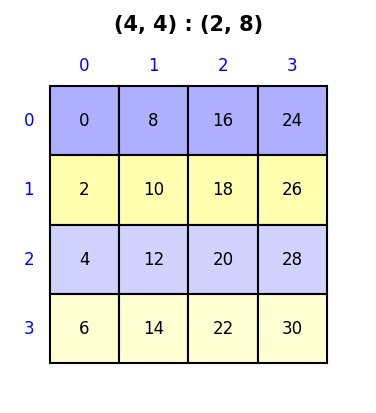

In [14]:
# Admissibility check: does an instruction's access pattern fit within a data layout?
#
# Data layout A maps a 4x4 logical grid to physical offsets with stride-2 gaps
A = Layout((4, 4), (2, 8))
A_li = left_inverse(A)

print(f"Data layout A = {A}")
print(f"  Image of A: {sorted(set(A(k) for k in range(size(A))))}")
print(f"  Left-inverse A† = {A_li}")
print()
draw_layout(A, colorize=True)

In [15]:
# Instruction T1: accesses every-other offset (0, 2, 4, 6) — all in the image of A
T_good = Layout(4, 2)
print(f"Instruction T = {T_good}")
print(f"  Accesses offsets: {[T_good(i) for i in range(size(T_good))]}")
print()

# Check admissibility: A(A†(T(i))) == T(i) for all i
print("Admissibility check:")
admissible = True
for i in range(size(T_good)):
    ti = T_good(i)
    coord = A_li(ti)
    roundtrip = A(coord)
    ok = (roundtrip == ti)
    admissible = admissible and ok
    print(f"  i={i}: T(i)={ti}, A†(T(i))={coord}, A(A†(T(i)))={roundtrip}  {'✓' if ok else '✗'}")

print(f"\nAdmissible: {admissible}")
print("All instruction offsets exist in the data layout.")

Instruction T = 4 : 2
  Accesses offsets: [0, 2, 4, 6]

Admissibility check:
  i=0: T(i)=0, A†(T(i))=0, A(A†(T(i)))=0  ✓
  i=1: T(i)=2, A†(T(i))=1, A(A†(T(i)))=2  ✓
  i=2: T(i)=4, A†(T(i))=2, A(A†(T(i)))=4  ✓
  i=3: T(i)=6, A†(T(i))=3, A(A†(T(i)))=6  ✓

Admissible: True
All instruction offsets exist in the data layout.


In [16]:
# Instruction T2: accesses consecutive offsets (0, 1, 2, 3)
# Offsets 1 and 3 are NOT in the image of A (which only has even offsets)
T_bad = Layout(4, 1)
print(f"Instruction T = {T_bad}")
print(f"  Accesses offsets: {[T_bad(i) for i in range(size(T_bad))]}")
print()

# Check admissibility
print("Admissibility check:")
admissible = True
for i in range(size(T_bad)):
    ti = T_bad(i)
    coord = A_li(ti)
    roundtrip = A(coord)
    ok = (roundtrip == ti)
    admissible = admissible and ok
    print(f"  i={i}: T(i)={ti}, A†(T(i))={coord}, A(A†(T(i)))={roundtrip}  {'✓' if ok else '✗'}")

print(f"\nAdmissible: {admissible}")
print("Odd offsets are not in the image of A, so this instruction is NOT admissible.")

Instruction T = 4 : 1
  Accesses offsets: [0, 1, 2, 3]

Admissibility check:
  i=0: T(i)=0, A†(T(i))=0, A(A†(T(i)))=0  ✓
  i=1: T(i)=1, A†(T(i))=16, A(A†(T(i)))=32  ✗
  i=2: T(i)=2, A†(T(i))=1, A(A†(T(i)))=2  ✓
  i=3: T(i)=3, A†(T(i))=17, A(A†(T(i)))=34  ✗

Admissible: False
Odd offsets are not in the image of A, so this instruction is NOT admissible.


In [17]:
# When admissible, A† ∘ T maps instruction coordinates to logical data coordinates
coord_map = compose(A_li, T_good)
print(f"Coordinate map A† ∘ T = {coord_map}")
print()
print("Instruction coord -> logical data coord -> physical offset:")
for i in range(size(T_good)):
    logical_coord = coord_map(i)
    physical_offset = A(logical_coord)
    print(f"  instr[{i}] -> logical coord {logical_coord} -> offset {physical_offset}")

Coordinate map A† ∘ T = 4 : 1

Instruction coord -> logical data coord -> physical offset:
  instr[0] -> logical coord 0 -> offset 0
  instr[1] -> logical coord 1 -> offset 2
  instr[2] -> logical coord 2 -> offset 4
  instr[3] -> logical coord 3 -> offset 6
